In [2]:
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import tiktoken

# 본인 프로젝트 경로
PROJECT_ROOT = Path(r"C:\Users\asguug\Documents\rag-agent")

# 혹시 다른 위치에서 실행할 경우 대비
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DOCS_DIR = PROJECT_ROOT / "data" / "docs"
EVAL_DIR = PROJECT_ROOT / "data" / "eval"
FIG_DIR = PROJECT_ROOT / "docs" / "figures"

EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

md_files = sorted(DOCS_DIR.glob("*.md"))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DOCS_DIR:", DOCS_DIR)
print("Markdown 문서 수:", len(md_files))

for path in md_files:
    print("-", path.name)

assert md_files, f"Markdown 문서가 없습니다. 경로 확인 필요: {DOCS_DIR}"

PROJECT_ROOT: C:\Users\asguug\Documents\rag-agent
DOCS_DIR: C:\Users\asguug\Documents\rag-agent\data\docs
Markdown 문서 수: 5
- baldurs_gate_3.md
- cyberpunk_2077.md
- hollow_knight.md
- monster_hunter_world.md
- no_mans_sky.md


In [3]:
encoding = tiktoken.get_encoding("cl100k_base")


def count_tokens(text: str) -> int:
    return len(encoding.encode(text))


def extract_title(text: str) -> str:
    match = re.search(r"^#\s+(.+)$", text, flags=re.MULTILINE)
    return match.group(1).strip() if match else ""


def extract_metadata(text: str) -> dict:
    """
    ## Metadata 섹션의 '- key: value' 형태를 dict로 변환
    """
    metadata = {}

    match = re.search(
        r"^## Metadata\s*(.*?)(?=^##\s+|\Z)",
        text,
        flags=re.MULTILINE | re.DOTALL,
    )

    if not match:
        return metadata

    metadata_text = match.group(1)

    for line in metadata_text.splitlines():
        line = line.strip()
        if not line.startswith("- "):
            continue

        item = line[2:]
        if ":" not in item:
            continue

        key, value = item.split(":", 1)
        metadata[key.strip()] = value.strip()

    return metadata


def split_h2_sections(text: str) -> list[dict]:
    """
    Markdown의 ## 헤더 기준으로 섹션 분리
    """
    pattern = re.compile(r"^##\s+(.+)$", flags=re.MULTILINE)
    matches = list(pattern.finditer(text))

    sections = []

    for i, match in enumerate(matches):
        section_name = match.group(1).strip()
        start = match.start()

        if i + 1 < len(matches):
            end = matches[i + 1].start()
        else:
            end = len(text)

        section_text = text[start:end].strip()

        sections.append(
            {
                "section": section_name,
                "text": section_text,
            }
        )

    return sections


def count_heading(text: str, level: int) -> int:
    return len(re.findall(rf"^{'#' * level}\s+", text, flags=re.MULTILINE))


def has_markdown_table(text: str) -> bool:
    return bool(re.search(r"^\|.+\|\s*$", text, flags=re.MULTILINE))


def has_markdown_image(text: str) -> bool:
    return bool(re.search(r"!\[.*?\]\(.*?\)", text))


def simplify_text(text: str) -> str:
    return re.sub(r"[^a-z0-9가-힣]+", " ", text.lower()).strip()

In [4]:
doc_records = []
section_records = []
news_records = []

all_clean_lines = []

for path in md_files:
    text = path.read_text(encoding="utf-8")
    metadata = extract_metadata(text)
    title = extract_title(text) or metadata.get("title", "")
    sections = split_h2_sections(text)

    review_count = len(re.findall(r"^###\s+Review\s+\d+", text, flags=re.MULTILINE))
    news_count = len(re.findall(r"^###\s+News\s+\d+:", text, flags=re.MULTILINE))

    doc_records.append(
        {
            "file": path.name,
            "game_key": metadata.get("game_key", path.stem),
            "title": title,
            "appid": metadata.get("appid", ""),
            "release_date": metadata.get("release_date", ""),
            "char_count": len(text),
            "line_count": len(text.splitlines()),
            "token_count": count_tokens(text),
            "h2_count": count_heading(text, 2),
            "h3_count": count_heading(text, 3),
            "review_count": review_count,
            "news_count": news_count,
            "has_metadata": bool(metadata),
            "has_table": has_markdown_table(text),
            "has_image": has_markdown_image(text),
        }
    )

    for section in sections:
        section_name = section["section"]
        section_text = section["text"]

        section_records.append(
            {
                "file": path.name,
                "game_key": metadata.get("game_key", path.stem),
                "title": title,
                "section": section_name,
                "char_count": len(section_text),
                "line_count": len(section_text.splitlines()),
                "token_count": count_tokens(section_text),
                "h3_count": count_heading(section_text, 3),
            }
        )

    # News 제목 추출
    for match in re.finditer(r"^###\s+News\s+\d+:\s*(.+)$", text, flags=re.MULTILINE):
        news_title = match.group(1).strip()

        simplified_game_title = simplify_text(title)
        simplified_news_title = simplify_text(news_title)

        # 게임 전체 제목이 뉴스 제목에 들어가는지 간단 체크
        title_match = simplified_game_title in simplified_news_title

        news_records.append(
            {
                "file": path.name,
                "game_key": metadata.get("game_key", path.stem),
                "game_title": title,
                "news_title": news_title,
                "title_match": title_match,
            }
        )

    # 반복 문장 탐지용
    for line in text.splitlines():
        line = line.strip()
        if len(line) >= 30 and not line.startswith("#"):
            all_clean_lines.append(line)

doc_df = pd.DataFrame(doc_records)
section_df = pd.DataFrame(section_records)
news_df = pd.DataFrame(news_records)

display(doc_df)
display(section_df.head(20))
display(news_df.head(20))

,file,game_key,title,appid,release_date,char_count,line_count,token_count,h2_count,h3_count,review_count,news_count,has_metadata,has_table,has_image
0,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,1086940,"Aug 3, 2023",14069,241,3522,5,25,20,5,True,False,False
1,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,1091500,"Dec 9, 2020",6752,296,2146,5,25,20,5,True,False,False
2,hollow_knight.md,hollow_knight,Hollow Knight,367520,"Feb 24, 2017",10256,238,2697,5,25,20,5,True,False,False
3,monster_hunter_world.md,monster_hunter_world,Monster Hunter: World,582010,"Aug 8, 2018",14354,238,3801,5,25,20,5,True,False,False
4,no_mans_sky.md,no_mans_sky,No Man's Sky,275850,"Aug 12, 2016",16266,291,4047,5,25,20,5,True,False,False


,file,game_key,title,section,char_count,line_count,token_count,h3_count
0,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Metadata,636,9,158,0
1,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Store Summary,224,2,50,0
2,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,About The Game,5376,19,1140,0
3,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Recent Steam Reviews,5101,166,1520,20
4,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Steam News and Updates,2704,39,644,5
5,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Metadata,514,9,131,0
6,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Store Summary,195,2,47,0
7,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,About The Game,65,3,18,0
8,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Recent Steam Reviews,3512,172,1184,20
9,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam News and Updates,2439,104,756,5


,file,game_key,game_title,news_title,title_match
0,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,The best possible fantasy author is writing a ...,True
1,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Baldur's Gate 3 YouTuber discovers 'time trave...,True
2,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Astarion's actor from Baldur's Gate 3 has dodg...,True
3,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Baldur's Gate 3 gets a new hotfix to fix the o...,True
4,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Hotfix #36 Now Live!,False
5,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Cyberpunk 2077 gets a whole new ending thanks ...,True
6,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 21 Apr — ...,False
7,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Cyberpunk 2077's funkiest vehicle modder has r...,True
8,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 24 Mar — ...,False
9,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 17 Mar — ...,False


In [5]:
doc_df_sorted = doc_df.sort_values("token_count", ascending=False)

display(
    doc_df_sorted[
        [
            "file",
            "title",
            "token_count",
            "char_count",
            "review_count",
            "news_count",
            "h2_count",
            "h3_count",
        ]
    ]
)

print("문서 토큰 수 통계")
display(doc_df["token_count"].describe())

print("섹션 토큰 수 통계")
display(section_df["token_count"].describe())

,file,title,token_count,char_count,review_count,news_count,h2_count,h3_count
4,no_mans_sky.md,No Man's Sky,4047,16266,20,5,5,25
3,monster_hunter_world.md,Monster Hunter: World,3801,14354,20,5,5,25
0,baldurs_gate_3.md,Baldur's Gate 3,3522,14069,20,5,5,25
2,hollow_knight.md,Hollow Knight,2697,10256,20,5,5,25
1,cyberpunk_2077.md,Cyberpunk 2077,2146,6752,20,5,5,25


문서 토큰 수 통계


count       5.000000
mean     3242.600000
std       796.420931
min      2146.000000
25%      2697.000000
50%      3522.000000
75%      3801.000000
max      4047.000000
Name: token_count, dtype: float64

섹션 토큰 수 통계


count      25.000000
mean      646.800000
std       607.431478
min        18.000000
25%        96.000000
50%       644.000000
75%      1137.000000
max      2087.000000
Name: token_count, dtype: float64

saved: C:\Users\asguug\Documents\rag-agent\docs\figures\week4_doc_token_counts.png


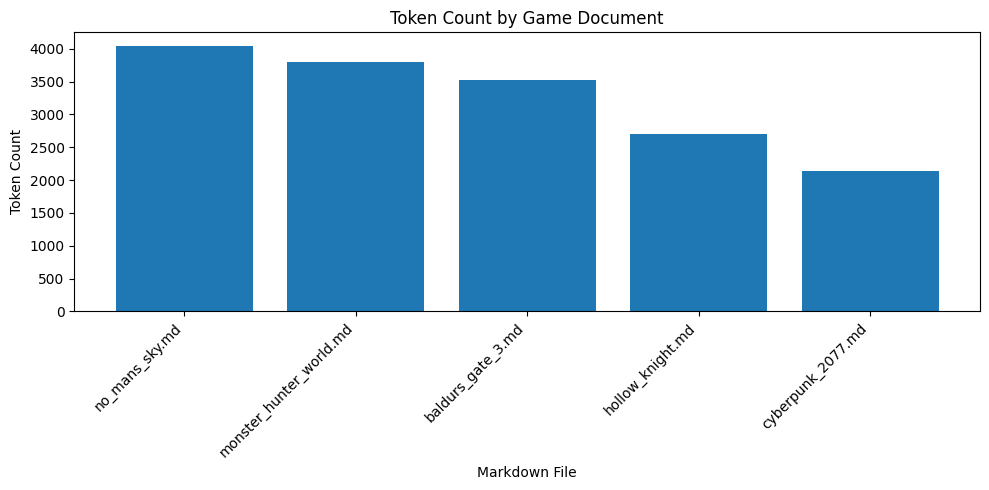

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(doc_df_sorted["file"], doc_df_sorted["token_count"])

plt.title("Token Count by Game Document")
plt.xlabel("Markdown File")
plt.ylabel("Token Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIG_DIR / "week4_doc_token_counts.png"
plt.savefig(output_path, dpi=150)

print("saved:", output_path)

plt.show()

In [7]:
section_summary = (
    section_df
    .groupby("section")
    .agg(
        section_count=("section", "count"),
        avg_tokens=("token_count", "mean"),
        min_tokens=("token_count", "min"),
        max_tokens=("token_count", "max"),
        total_tokens=("token_count", "sum"),
    )
    .reset_index()
)

section_summary["avg_tokens"] = section_summary["avg_tokens"].round(1)

display(section_summary.sort_values("total_tokens", ascending=False))

,section,section_count,avg_tokens,min_tokens,max_tokens,total_tokens
2,Recent Steam Reviews,5,1451.2,1137,2087,7256
3,Steam News and Updates,5,975.4,644,1677,4877
0,About The Game,5,626.6,18,1140,3133
1,Metadata,5,136.2,96,169,681
4,Store Summary,5,44.6,23,53,223


In [8]:
placeholder_patterns = {
    "no_short_description": r"No short description found\.",
    "no_detailed_description": r"No detailed store description found\.",
    "no_recent_reviews": r"No recent reviews found\.",
    "no_news_items": r"No news items found\.",
}

noise_records = []

for path in md_files:
    text = path.read_text(encoding="utf-8")

    record = {
        "file": path.name,
        "empty_line_count": sum(1 for line in text.splitlines() if not line.strip()),
        "table_exists": has_markdown_table(text),
        "image_exists": has_markdown_image(text),
    }

    for noise_name, pattern in placeholder_patterns.items():
        record[noise_name] = len(re.findall(pattern, text))

    noise_records.append(record)

noise_df = pd.DataFrame(noise_records)

display(noise_df)

,file,empty_line_count,table_exists,image_exists,no_short_description,no_detailed_description,no_recent_reviews,no_news_items
0,baldurs_gate_3.md,62,False,False,0,0,0,0
1,cyberpunk_2077.md,63,False,False,0,0,0,0
2,hollow_knight.md,53,False,False,0,0,0,0
3,monster_hunter_world.md,57,False,False,0,0,0,0
4,no_mans_sky.md,88,False,False,0,0,0,0


In [9]:
line_counter = Counter(all_clean_lines)

repeated_lines = [
    {"line": line, "count": count}
    for line, count in line_counter.items()
    if count >= 2
]

repeated_df = pd.DataFrame(repeated_lines)

if len(repeated_df) > 0:
    repeated_df = repeated_df.sort_values("count", ascending=False)
    display(repeated_df.head(30))
else:
    print("반복 문장은 크게 발견되지 않았습니다.")

,line,count
0,* excluding free to play games,3
1,Call of Duty®: Modern Warfare®,2


In [14]:
if len(news_df) > 0:
    title_not_included = news_df[news_df["game_title_in_news_title"] == False].copy()

    print("전체 News 수:", len(news_df))
    print("뉴스 제목에 게임명이 직접 포함되지 않은 항목 수:", len(title_not_included))
    print("주의: 이 항목들은 노이즈 확정이 아니라 검토 후보입니다.")

    display(title_not_included)
else:
    print("News 항목이 없습니다.")

전체 News 수: 25
뉴스 제목에 게임명이 직접 포함되지 않은 항목 수: 11
주의: 이 항목들은 노이즈 확정이 아니라 검토 후보입니다.


,file,game_key,game_title,news_title,game_title_in_news_title
4,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Hotfix #36 Now Live!,False
6,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 21 Apr — ...,False
8,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 24 Mar — ...,False
9,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 17 Mar — ...,False
10,hollow_knight.md,hollow_knight,Hollow Knight,Patch Version 1.5.12620 Now Live,False
13,hollow_knight.md,hollow_knight,Hollow Knight,Patch Version 1.5.12459 Now Live,False
15,monster_hunter_world.md,monster_hunter_world,Monster Hunter: World,Monster Hunter news,False
16,monster_hunter_world.md,monster_hunter_world,Monster Hunter: World,Related Promotional Information,False
17,monster_hunter_world.md,monster_hunter_world,Monster Hunter: World,UPDATE - Postponed: Monster Hunter Showcase co...,False
18,monster_hunter_world.md,monster_hunter_world,Monster Hunter: World,Pre-Order Monster Hunter Stories 3: Twisted Re...,False


In [15]:
def classify_news_relevance(title: str) -> str:
    title_lower = title.lower()

    if any(keyword in title_lower for keyword in ["hotfix", "patch", "update", "version", "now live"]):
        return "valid_update_or_patch"

    if any(keyword in title_lower for keyword in ["top sellers", "sale", "discount"]):
        return "store_or_sales_related"

    if any(keyword in title_lower for keyword in ["pre-order", "promotional", "showcase"]):
        return "franchise_or_promotion_related"

    if any(keyword in title_lower for keyword in ["support notice", "windows 10", "end of support"]):
        return "support_or_platform_notice"

    return "manual_review_needed"


news_df["relevance_type"] = news_df["news_title"].apply(classify_news_relevance)

display(news_df.sort_values(["game_key", "relevance_type"]))

,file,game_key,game_title,news_title,game_title_in_news_title,relevance_type
0,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,The best possible fantasy author is writing a ...,True,manual_review_needed
1,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Baldur's Gate 3 YouTuber discovers 'time trave...,True,manual_review_needed
2,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Astarion's actor from Baldur's Gate 3 has dodg...,True,manual_review_needed
3,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Baldur's Gate 3 gets a new hotfix to fix the o...,True,valid_update_or_patch
4,baldurs_gate_3.md,baldurs_gate_3,Baldur's Gate 3,Hotfix #36 Now Live!,False,valid_update_or_patch
5,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Cyberpunk 2077 gets a whole new ending thanks ...,True,manual_review_needed
7,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Cyberpunk 2077's funkiest vehicle modder has r...,True,manual_review_needed
6,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 21 Apr — ...,False,store_or_sales_related
8,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 24 Mar — ...,False,store_or_sales_related
9,cyberpunk_2077.md,cyberpunk_2077,Cyberpunk 2077,Steam Global Top Sellers for week of 17 Mar — ...,False,store_or_sales_related


In [18]:
total_docs = len(doc_df)
total_tokens = int(doc_df["token_count"].sum())
avg_tokens = round(doc_df["token_count"].mean(), 1)
min_tokens = int(doc_df["token_count"].min())
max_tokens = int(doc_df["token_count"].max())

total_sections = len(section_df)

# 주요 섹션 이름 정리
if "section_summary" in globals() and len(section_summary) > 0:
    main_sections = ", ".join(section_summary["section"].tolist())
else:
    main_sections = ", ".join(sorted(section_df["section"].unique()))

# news_df가 있는 경우만 News 진단
news_total_count = 0
title_not_included_count = 0
relevance_summary_text = "News 데이터가 없어 별도 relevance type 분석은 수행하지 않았다."

if "news_df" in globals() and len(news_df) > 0:
    news_total_count = len(news_df)

    # 기존 컬럼명이 title_match인 경우 호환 처리
    if "game_title_in_news_title" not in news_df.columns:
        if "title_match" in news_df.columns:
            news_df = news_df.rename(columns={"title_match": "game_title_in_news_title"})
        else:
            news_df["game_title_in_news_title"] = False

    title_not_included_count = int((news_df["game_title_in_news_title"] == False).sum())    

    relevance_counts = news_df["relevance_type"].value_counts().to_dict()

    relevance_lines = []
    for key, value in relevance_counts.items():
        relevance_lines.append(f"- {key}: {value}개")

    relevance_summary_text = "\n".join(relevance_lines)

summary_text = f"""
## 데이터 품질 진단 요약

이번 4주차 데이터 품질 진단은 `data/docs/`에 저장된 Steam 게임 Markdown 문서를 대상으로 수행했다.
전체 문서 수는 {total_docs}개이며, 총 토큰 수는 약 {total_tokens}개이다.
문서별 토큰 수는 최소 {min_tokens}개, 최대 {max_tokens}개, 평균 {avg_tokens}개로 확인되었다.

문서 구조는 Markdown 기반이며, 주요 섹션은 다음과 같다.

- Metadata
- Store Summary
- About The Game
- Recent Steam Reviews
- Steam News and Updates

현재 데이터는 표나 이미지보다는 텍스트 중심으로 구성되어 있다.
각 문서는 게임 단위로 분리되어 있으며, section 구조가 명확하기 때문에 단순 길이 기준 chunking만 적용하기보다는 Markdown 헤더와 section metadata를 함께 활용하는 방식이 적합하다고 판단했다.

### News 데이터 진단

Steam News 데이터는 appid 기준으로 수집했기 때문에 수집 자체가 잘못된 것은 아니다.
다만 전체 News {news_total_count}개 중 뉴스 제목에 게임명이 직접 포함되지 않은 항목은 {title_not_included_count}개로 확인되었다.

이 항목들을 모두 노이즈로 단정하기는 어렵다.
예를 들어 `Hotfix`, `Patch Version`, `Update`와 같은 제목은 게임명이 직접 포함되지 않아도 실제 패치나 업데이트 공지일 가능성이 높다.
반면 `Steam Global Top Sellers`, `Related Promotional Information`, 다른 시리즈의 `Pre-Order` 뉴스처럼 특정 게임의 플레이 스타일이나 업데이트 내용을 묻는 질문에는 검색 품질을 떨어뜨릴 수 있는 항목도 존재한다.

따라서 이번 분석에서는 `게임명 미포함 = 노이즈`로 처리하지 않고, 검색 목적에 따라 relevance type을 나누는 방식이 더 적절하다고 판단했다.

News relevance type 분포는 다음과 같다.

{relevance_summary_text}

### 전처리 및 검색 개선 가설

1. 플레이 스타일 질문에서는 `About The Game`, `Store Summary` 섹션을 우선 검색한다.
2. 최근 리뷰나 유저 반응 질문에서는 `Recent Steam Reviews` 섹션을 우선 검색한다.
3. 업데이트 관련 질문에서는 `Steam News and Updates` 섹션 중 `valid_update_or_patch` 유형을 우선 검색한다.
4. 판매 순위, 프로모션, 다른 시리즈 관련 뉴스는 기본 추천 근거에서는 낮은 우선순위로 처리한다.
5. 향후 5주차 retrieval 고도화에서는 `section`, `game_key`, `relevance_type` metadata를 활용해 질문 의도별 필터링 검색을 적용할 수 있다.

결론적으로 현재 데이터의 핵심 문제는 수집 오류라기보다는, 서로 다른 성격의 정보가 같은 News 섹션에 함께 들어가 있다는 점이다.
따라서 4주차 chunking 실험에서는 문서의 Markdown 구조와 metadata를 보존하는 chunking 전략이 필요하다고 판단했다.
"""

print(summary_text)


## 데이터 품질 진단 요약

이번 4주차 데이터 품질 진단은 `data/docs/`에 저장된 Steam 게임 Markdown 문서를 대상으로 수행했다.
전체 문서 수는 5개이며, 총 토큰 수는 약 16213개이다.
문서별 토큰 수는 최소 2146개, 최대 4047개, 평균 3242.6개로 확인되었다.

문서 구조는 Markdown 기반이며, 주요 섹션은 다음과 같다.

- Metadata
- Store Summary
- About The Game
- Recent Steam Reviews
- Steam News and Updates

현재 데이터는 표나 이미지보다는 텍스트 중심으로 구성되어 있다.
각 문서는 게임 단위로 분리되어 있으며, section 구조가 명확하기 때문에 단순 길이 기준 chunking만 적용하기보다는 Markdown 헤더와 section metadata를 함께 활용하는 방식이 적합하다고 판단했다.

### News 데이터 진단

Steam News 데이터는 appid 기준으로 수집했기 때문에 수집 자체가 잘못된 것은 아니다.
다만 전체 News 25개 중 뉴스 제목에 게임명이 직접 포함되지 않은 항목은 11개로 확인되었다.

이 항목들을 모두 노이즈로 단정하기는 어렵다.
예를 들어 `Hotfix`, `Patch Version`, `Update`와 같은 제목은 게임명이 직접 포함되지 않아도 실제 패치나 업데이트 공지일 가능성이 높다.
반면 `Steam Global Top Sellers`, `Related Promotional Information`, 다른 시리즈의 `Pre-Order` 뉴스처럼 특정 게임의 플레이 스타일이나 업데이트 내용을 묻는 질문에는 검색 품질을 떨어뜨릴 수 있는 항목도 존재한다.

따라서 이번 분석에서는 `게임명 미포함 = 노이즈`로 처리하지 않고, 검색 목적에 따라 relevance type을 나누는 방식이 더 적절하다고 판단했다.

News relevance type 분포는 다음과 같다.

- valid_updat